# 3. Exploratory Data Analysis (EDA)

## 3.1 Univariate Analysis

In [1]:
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np

In [3]:
dataset=pd.read_csv("phishing_preprocessed.csv")

### 3.1.1 Qualitative and Quantitative Variables                              

In [4]:
print("Qualitative Variables: status")
print("Quantitative Variables:")
print(dataset.drop(columns=["status"]).columns.tolist())

Qualitative Variables: status
Quantitative Variables:
['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperli

### 3.1.2 Central Tendency                                 

In [5]:
quan=dataset.drop(columns=["status"]).columns
descriptive=pd.DataFrame(index=["Mean","Median","Mode"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]

In [6]:
descriptive

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
Mean,61.126684,21.090289,0.150569,2.480752,0.99755,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,856756.643307,0.020122,0.533946,3.185739
Median,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Mode,26,16,0,2,0,0,0,0,0,0,...,0,1,0,0,0,-1,0,0,1,0


### 3.1.3 Percentile

In [7]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                                "Q3:75%","Q4:100%"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]

In [8]:
descriptive

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
Mean,61.126684,21.090289,0.150569,2.480752,0.99755,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,856756.643307,0.020122,0.533946,3.185739
Median,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Mode,26,16,0,2,0,0,0,0,0,0,...,0,1,0,0,0,-1,0,0,1,0
Q1:25%,33.0,15.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,84.0,972.25,0.0,0.0,0.0,1.0
Q2:50%,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Q3:75%,71.0,24.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,449.0,7026.75,373845.5,0.0,1.0,5.0
Q4:100%,1641.0,214.0,1.0,24.0,43.0,4.0,3.0,19.0,0.0,19.0,...,1.0,1.0,1.0,1.0,29829.0,12874.0,10767986.0,1.0,1.0,10.0


### 3.1.4 IQR

In [9]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                                "Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]- descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Max"]=dataset[columnName].max()

In [10]:
descriptive

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
Mean,61.126684,21.090289,0.150569,2.480752,0.99755,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,856756.643307,0.020122,0.533946,3.185739
Median,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Mode,26,16,0,2,0,0,0,0,0,0,...,0,1,0,0,0,-1,0,0,1,0
Q1:25%,33.0,15.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,84.0,972.25,0.0,0.0,0.0,1.0
Q2:50%,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Q3:75%,71.0,24.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,449.0,7026.75,373845.5,0.0,1.0,5.0
Q4:100%,1641.0,214.0,1.0,24.0,43.0,4.0,3.0,19.0,0.0,19.0,...,1.0,1.0,1.0,1.0,29829.0,12874.0,10767986.0,1.0,1.0,10.0
IQR,38.0,9.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,365.0,6054.5,373845.5,0.0,1.0,4.0
1.5rule,57.0,13.5,0.0,1.5,1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.5,0.0,547.5,9081.75,560768.25,0.0,1.5,6.0
Lesser,-24.0,1.5,0.0,0.5,-1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.5,0.0,-463.5,-8109.5,-560768.25,0.0,-1.5,-5.0


### 3.1.5 Outlier Detection

In [11]:
lesser=[]
greater=[]
for columnName in quan:
    if(descriptive[columnName]["Min"]<descriptive[columnName]["Lesser"]):
        lesser.append(columnName)
    if(descriptive[columnName]["Max"]>descriptive[columnName]["Greater"]):
        greater.append(columnName)
print("Lower Outlier Columns:")
print(lesser)
print("\nUpper Outlier Columns:")
print(greater)

Lower Outlier Columns:
['domain_in_title']

Upper Outlier Columns:
['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_com', 'nb_dslash', 'http_in_path', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'nb_extCSS', 'ratio_extRedirection', 'ratio_extErrors', 'login_form', 'ratio_e

### 3.1.6 Replace Outliers

In [12]:
for columnName in lesser:
    if dataset[columnName].nunique()>2:
        dataset.loc[dataset[columnName]<descriptive[columnName]["Lesser"],columnName]=descriptive[columnName]["Lesser"]
for columnName in greater:
    if dataset[columnName].nunique()>2:
        dataset.loc[dataset[columnName]>descriptive[columnName]["Greater"],columnName]=descriptive[columnName]["Greater"]

### 3.1.7 Updated Descriptive Table

In [13]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                                "Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]- descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Max"]=dataset[columnName].max()

In [14]:
descriptive

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
Mean,56.327822,20.302843,0.150569,2.38937,0.64685,0.0,0.0,0.0,0.0,0.0,...,0.124759,0.775853,0.439545,0.072878,344.670297,4062.543745,233790.719466,0.020122,0.533946,3.185739
Median,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Mode,128,16.0,0,2.0,0.0,0,0,0,0,0,...,0,1,0,0,996.5,-1,0.0,0,1,0
Q1:25%,33.0,15.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,84.0,972.25,0.0,0.0,0.0,1.0
Q2:50%,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Q3:75%,71.0,24.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,449.0,7026.75,373845.5,0.0,1.0,5.0
Q4:100%,128.0,37.5,1.0,4.5,2.5,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,996.5,12874.0,934613.75,1.0,1.0,10.0
IQR,38.0,9.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,365.0,6054.5,373845.5,0.0,1.0,4.0
1.5rule,57.0,13.5,0.0,1.5,1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.5,0.0,547.5,9081.75,560768.25,0.0,1.5,6.0
Lesser,-24.0,1.5,0.0,0.5,-1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.5,0.0,-463.5,-8109.5,-560768.25,0.0,-1.5,-5.0


### 3.1.8 Check Outliers

In [15]:
lesser=[]
greater=[]
for columnName in quan:
    if dataset[columnName].nunique()>2:
        if(descriptive[columnName]["Min"]<descriptive[columnName]["Lesser"]):
            lesser.append(columnName)
        if(descriptive[columnName]["Max"]>descriptive[columnName]["Greater"]):
            greater.append(columnName)
print("Lower Outlier Columns:")
print(lesser)
print("\nUpper Outlier Columns:")
print(greater)

Lower Outlier Columns:
[]

Upper Outlier Columns:
[]


### 3.1.9 Frequency

In [16]:
for columnName in quan:
    freqTable=pd.DataFrame(columns=["Unique_Values","Frequency","Relative_Frequency","Cumsum"])
    freqTable["Unique_Values"]=dataset[columnName].value_counts().index
    freqTable["Frequency"]=dataset[columnName].value_counts().values
    freqTable["Relative_Frequency"]=freqTable["Frequency"]/len(dataset)
    freqTable["Cumsum"]=freqTable["Relative_Frequency"].cumsum()
    print("\nFrequency Table:",columnName)
    display(freqTable)


Frequency Table: length_url


,Unique_Values,Frequency,Relative_Frequency,Cumsum
0,128,686,0.060017,0.060017
1,26,251,0.021960,0.081977
2,29,250,0.021872,0.103850
3,32,250,0.021872,0.125722
4,27,230,0.020122,0.145844
...,...,...,...,...
112,108,14,0.001225,0.998425
113,116,11,0.000962,0.999388
114,13,4,0.000350,0.999738
115,14,2,0.000175,0.999913



Frequency Table: length_hostname


,Unique_Values,Frequency,Relative_Frequency,Cumsum
0,16.0,956,0.083640,0.083640
1,37.5,775,0.067804,0.151444
2,15.0,754,0.065967,0.217410
3,18.0,731,0.063955,0.281365
4,17.0,725,0.063430,0.344794
5,14.0,702,0.061417,0.406212
6,19.0,586,0.051269,0.457480
7,20.0,577,0.050481,0.507962
8,21.0,561,0.049081,0.557043
9,13.0,531,0.046457,0.603500



Frequency Table: ip


...

,Unique_Values,Frequency,Relative_Frequency,Cumsum
0,0,11200,0.979878,0.979878
1,1,230,0.020122,1.000000



Frequency Table: google_index


,Unique_Values,Frequency,Relative_Frequency,Cumsum
0,1,6103,0.533946,0.533946
1,0,5327,0.466054,1.000000



Frequency Table: page_rank


,Unique_Values,Frequency,Relative_Frequency,Cumsum
0,0,2666,0.233246,0.233246
1,5,2057,0.179965,0.413211
2,2,1553,0.135871,0.549081
3,4,1380,0.120735,0.669816
4,3,1232,0.107787,0.777603
5,1,735,0.064304,0.841907
6,6,727,0.063605,0.905512
7,7,509,0.044532,0.950044
8,10,269,0.023535,0.973578
9,8,262,0.022922,0.996500


### 3.1.10 HSK

In [17]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                                "Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max",
                                "Kurtosis","Skewness"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]- descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Max"]=dataset[columnName].max()
    descriptive[columnName]["Kurtosis"]=dataset[columnName].kurtosis()
    descriptive[columnName]["Skewness"]=dataset[columnName].skew()

In [18]:
descriptive

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
Mean,56.327822,20.302843,0.150569,2.38937,0.64685,0.0,0.0,0.0,0.0,0.0,...,0.124759,0.775853,0.439545,0.072878,344.670297,4062.543745,233790.719466,0.020122,0.533946,3.185739
Median,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Mode,128,16.0,0,2.0,0.0,0,0,0,0,0,...,0,1,0,0,996.5,-1,0.0,0,1,0
Q1:25%,33.0,15.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,84.0,972.25,0.0,0.0,0.0,1.0
Q2:50%,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Q3:75%,71.0,24.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,449.0,7026.75,373845.5,0.0,1.0,5.0
Q4:100%,128.0,37.5,1.0,4.5,2.5,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,996.5,12874.0,934613.75,1.0,1.0,10.0
IQR,38.0,9.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,365.0,6054.5,373845.5,0.0,1.0,4.0
1.5rule,57.0,13.5,0.0,1.5,1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.5,0.0,547.5,9081.75,560768.25,0.0,1.5,6.0
Lesser,-24.0,1.5,0.0,0.5,-1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.5,0.0,-463.5,-8109.5,-560768.25,0.0,-1.5,-5.0


### 3.1.11 Variance and Std Deviation

In [19]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                                "Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater",
                                    "Min","Max","Kurtosis","Skewness","Variance","Std"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]- descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Max"]=dataset[columnName].max() 
    descriptive[columnName]["Kurtosis"]=dataset[columnName].kurtosis()
    descriptive[columnName]["Skewness"]=dataset[columnName].skew()
    descriptive[columnName]["Variance"]=dataset[columnName].var()
    descriptive[columnName]["Std"]=dataset[columnName].std()

In [20]:
descriptive

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
Mean,56.327822,20.302843,0.150569,2.38937,0.64685,0.0,0.0,0.0,0.0,0.0,...,0.124759,0.775853,0.439545,0.072878,344.670297,4062.543745,233790.719466,0.020122,0.533946,3.185739
Median,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Mode,128,16.0,0,2.0,0.0,0,0,0,0,0,...,0,1,0,0,996.5,-1,0.0,0,1,0
Q1:25%,33.0,15.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,84.0,972.25,0.0,0.0,0.0,1.0
Q2:50%,47.0,19.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,242.0,3993.0,1651.0,0.0,1.0,3.0
Q3:75%,71.0,24.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,449.0,7026.75,373845.5,0.0,1.0,5.0
Q4:100%,128.0,37.5,1.0,4.5,2.5,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,996.5,12874.0,934613.75,1.0,1.0,10.0
IQR,38.0,9.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,365.0,6054.5,373845.5,0.0,1.0,4.0
1.5rule,57.0,13.5,0.0,1.5,1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.5,0.0,547.5,9081.75,560768.25,0.0,1.5,6.0
Lesser,-24.0,1.5,0.0,0.5,-1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.5,0.0,-463.5,-8109.5,-560768.25,0.0,-1.5,-5.0


### 3.1.12 Normal Distribution

#### 3.1.12.1 Probability Density Function (PDF)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30824\3411217165.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(data,kde=True,kde_kws={'color':'blue'},color='green')


Mean=56.328,Standard Deviation=30.772


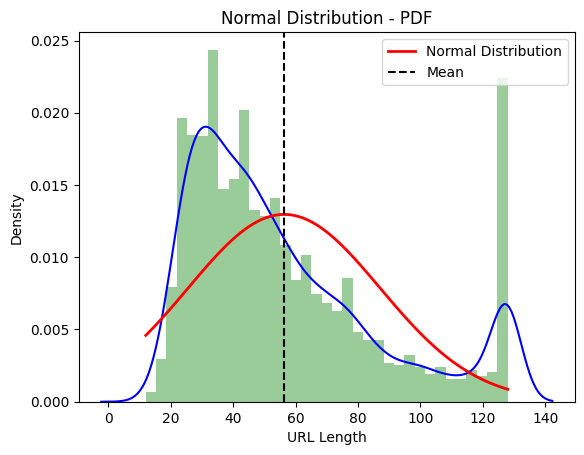

In [21]:
from matplotlib import pyplot
from scipy.stats import norm
import seaborn as sns

data=dataset["length_url"]
ax=sns.distplot(data,kde=True,kde_kws={'color':'blue'},color='green')

sample=data
sample_mean=sample.mean()
sample_std=sample.std()
print('Mean=%.3f,Standard Deviation=%.3f' %(sample_mean,sample_std))

dist=norm(sample_mean,sample_std)
values=np.arange(sample.min(),sample.max()+1)
probabilities=[dist.pdf(value) for value in values]

pyplot.plot(values,probabilities,color="red",linewidth=2,label="Normal Distribution")
pyplot.axvline(sample_mean,color="black",linestyle="--",label="Mean")

pyplot.title("Normal Distribution - PDF")
pyplot.xlabel("URL Length")
pyplot.ylabel("Density")
pyplot.legend()
pyplot.show()

#### 3.1.12.2 Cumulative Distribution Function (CDF)

Value = 47.0
Cumulative Probability = 0.5032370953630796


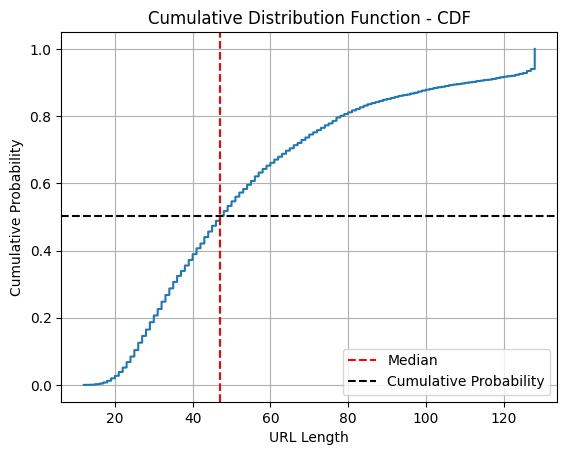

In [22]:
from statsmodels.distributions.empirical_distribution import ECDF
  
data=dataset["length_url"]
ecdf=ECDF(data)
value=data.median()
probability=ecdf(value)

print("Value =",value)
print("Cumulative Probability =",probability)

pyplot.plot(ecdf.x,ecdf.y)
pyplot.axvline(value,color="red",linestyle="--",label="Median")
pyplot.axhline(probability,color="black",linestyle="--",label="Cumulative Probability")

pyplot.title("Cumulative Distribution Function - CDF")
pyplot.xlabel("URL Length")
pyplot.ylabel("Cumulative Probability")
pyplot.legend()
pyplot.grid()
pyplot.show()

### 3.1.13 Standard Normal Distribution (Z-Score)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30824\2684539349.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True,kde_kws={"color":"blue"},color="green")


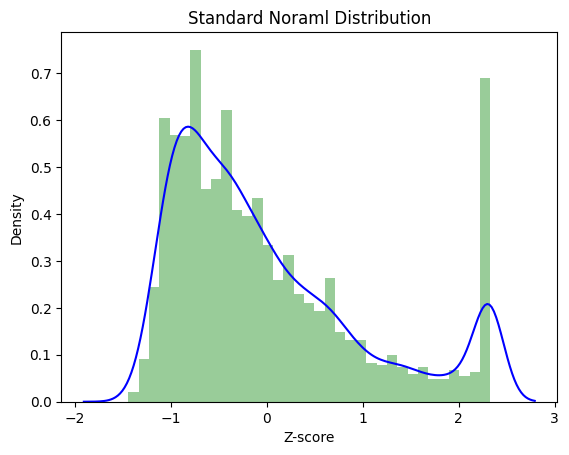

Mean of Z-score = -6.80315141248871e-17


In [23]:
data=dataset["length_url"]
mean=data.mean()
std=data.std()
values=[i for i in data]
z_score=[((j-mean)/std) for j in values]

sns.distplot(z_score,kde=True,kde_kws={"color":"blue"},color="green")
pyplot.title("Standard Noraml Distribution")
pyplot.xlabel("Z-score")
pyplot.ylabel("Density")
pyplot.show()

print("Mean of Z-score =",sum(z_score)/len(z_score))